# Coppinger, Bhushan & Jalali (1999)
## *Photonic Time Stretch and Its Application to A/D Conversion*
### IEEE Trans. Microwave Theory Tech., Vol. 47, No. 7, July 1999

**Computer Algebra System rewrite in SymPy + NumPy**
Every equation derived from first principles. English test-prep annotations on each result.

---
**Big idea:** A chirped optical pulse acts as a *time-magnifying lens*.
Disperse it, modulate it at RF, disperse again -> the RF signal is now stretched in time by M.
A slow ADC can digitize a 100 GHz signal if M=10. This is the foundation of STEAM microscopy.


In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
from dgs.coppinger1999 import (
    eq1_chirped_pulse_time, eq2_chirped_pulse_freq,
    eq3_modulated_time, eq4_modulated_freq, eq5_output_freq,
    eq8_stretch_factor, eq9_dispersion_penalty,
    eq7_detected_intensity, simulate_fig2,
    verify_fig2_stretch_factors, mzm_cmos_specs,
    freq_to_time_mapping, derive_appendix_time_domain,
    dispersive_transfer_function, appendix_gamma_definition,
    appendix_exponent_E1, mzm_transfer_function,
)
from dgs.coppinger1999 import t, f, fm, tau, beta2, L1, L2, a, PI
print("Imports OK")

Imports OK


## Section 1 — The Chirped Gaussian Pulse (Eq. 1-2)

A transform-limited (unchirped) Gaussian pulse of width $\tau$ enters fiber of length $L_1$.
GVD ($\beta_2$, second derivative of dispersion relation) chirps the pulse.

**Frequency-to-time key idea:** After propagation through dispersive fiber, the
instantaneous frequency of the pulse varies linearly with time. This is the
*direct time-to-wavelength* mapping that makes STEAM work.

$$E_{ch}(L_1, t) = \exp\!\left(-\frac{t^2}{\tau^2}\right)$$

In the frequency domain (Eq. 2) — the chirped Gaussian acquires a complex width:
$$E_{ch}(L_1, f) = \frac{\sqrt{\pi}}{\sqrt{\tau^{-2} + j/(2L_1\beta_2)}}
\exp\!\left(\frac{-\pi^2 f^2}{\tau^{-2} + j/(2L_1\beta_2)}\right)$$

**English test-prep note:** *chirp* = frequency changes over time (like a bird chirp rising in pitch).
In fiber, different colors travel at different speeds (GVD). A short pulse spreading in time
is acquiring chirp.


In [2]:
# --- Eq 1: chirped pulse in time ---
E1_t = eq1_chirped_pulse_time()
print("Eq(1) E_ch(L1,t) =")
sp.pprint(E1_t)

# --- Eq 2: in frequency domain ---
E2_f = eq2_chirped_pulse_freq()
print("Eq(2) E_ch(L1,f) =")
sp.pprint(E2_f)

Eq(1) E_ch(L1,t) =
   2 
 -t  
 ────
   2 
  τ  
ℯ    
Eq(2) E_ch(L1,f) =
                    2        2  2 
                -2⋅π ⋅L₁⋅β₂⋅f ⋅τ  
                ──────────────────
                               2  
        ____      2⋅L₁⋅β₂ + ⅈ⋅τ   
√2⋅√π⋅╲╱ L₁ ⋅τ⋅ℯ                  
──────────────────────────────────
             _____________        
            ╱           2         
           ╱         ⅈ⋅τ          
          ╱   2⋅L₁ + ────         
        ╲╱            β₂          


In [3]:
# Verify: at f=0 Eq(2) should reduce to sqrt(pi)/sqrt(tau^-2 + j/(2*L1*beta2))
f0_val = E2_f.subs(f, 0)
print("E_ch(L1, f=0) =", sp.simplify(f0_val))

# Physical check: complex denominator encodes both amplitude AND phase chirp
denom = tau**(-2) + sp.I / (2*L1*beta2)
print("Denominator (tau^-2 + j/2L1b2):")
sp.pprint(denom)
print("Magnitude =", sp.simplify(sp.Abs(denom)))

E_ch(L1, f=0) = sqrt(2)*sqrt(pi)*sqrt(L_1)*tau/sqrt(2*L_1 + I*tau**2/beta_2)
Denominator (tau^-2 + j/2L1b2):
1       ⅈ   
── + ───────
 2   2⋅L₁⋅β₂
τ           
Magnitude = sqrt(4*L_1**2*beta_2**2 + tau**4)/(2*L_1*tau**2*Abs(beta_2))


## Section 2 — Mach-Zehnder Modulator (Eq. 3-4)

The chirped pulse enters a **Mach-Zehnder Modulator (MZM)** — an interferometer
carved into silicon or LiNbO3 that encodes an RF signal onto the optical carrier.

**CMOS MZM physics:** The plasma dispersion effect in silicon shifts refractive index
when free carriers (electrons/holes from forward-biased p-n junction) are injected.
$\Delta n \propto \Delta N_e + \Delta N_h$ (Soref-Bennett 1987).

Small-signal (intensity) modulation (modulation depth $a \ll 1$):
$$E_{in}(L_1, t) = E_{ch}(L_1,t)\cdot[1 + a\cos(2\pi f_m t)] \quad \text{Eq.(3)}$$

In frequency domain (Eq. 4) — cosine becomes two delta functions (sidebands):
$$E_{in}(L_1, f) = E_{ch}(L_1,f) * \left[\delta(f) + \frac{a}{2}(\delta(f-f_m)+\delta(f+f_m))\right]$$


In [4]:
# --- Eq 3: modulated field ---
E3 = eq3_modulated_time()
print("Eq(3) E_in(L1,t) =")
sp.pprint(sp.expand_trig(E3))

# --- Eq 4: sidebands ---
sb = eq4_modulated_freq()
print("Carrier amplitude at f=0:")
sp.pprint(sp.simplify(sb['carrier']))
print("Upper sideband amplitude at f=+fm:")
sp.pprint(sp.simplify(sb['upper_sb']))

Eq(3) E_in(L1,t) =
                                2 
                              -t  
                              ────
                                2 
⎛  ⎛     2            ⎞    ⎞   τ  
⎝a⋅⎝2⋅cos (π⋅fₘ⋅t) - 1⎠ + 1⎠⋅ℯ    
Carrier amplitude at f=0:
          ____    
  √2⋅√π⋅╲╱ L₁ ⋅τ  
──────────────────
     _____________
    ╱           2 
   ╱         ⅈ⋅τ  
  ╱   2⋅L₁ + ──── 
╲╱            β₂  
Upper sideband amplitude at f=+fm:
                      2         2  2 
                  -2⋅π ⋅L₁⋅β₂⋅fₘ ⋅τ  
                  ───────────────────
                                 2   
        ____        2⋅L₁⋅β₂ + ⅈ⋅τ    
√2⋅√π⋅╲╱ L₁ ⋅a⋅τ⋅ℯ                   
─────────────────────────────────────
               _____________         
              ╱           2          
             ╱         ⅈ⋅τ           
        2⋅  ╱   2⋅L₁ + ────          
          ╲╱            β₂           


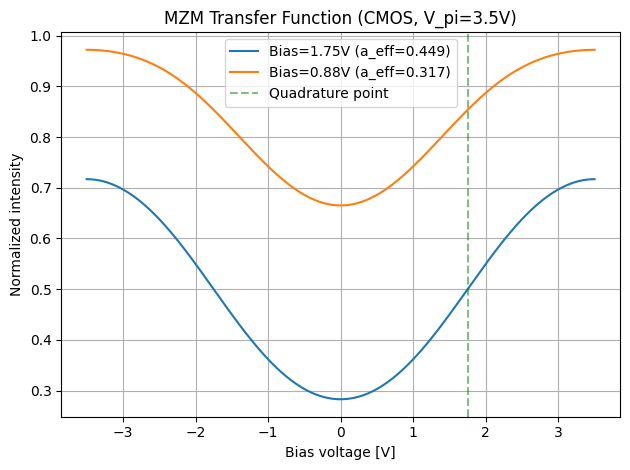

MZM CMOS specs:
  V_pi_V: 3.5
  V_pi_L_Vcm: 2.0
  bandwidth_3dB_GHz: 40
  insertion_loss_dB: 5
  extinction_ratio_dB: 30
  operating_wavelength_nm: 1550
  device_length_mm: 5
  cmos_node: 180nm silicon photonics
  physics: plasma dispersion effect: free carriers shift n and k
  connection_to_jalali: MZM output is Eq(3) — sets modulation depth a


In [5]:
# MZM transfer function plot (numeric)
t_arr = np.linspace(-np.pi, np.pi, 500)
V_pi = 3.5  # CMOS MZM
for V_bias in [V_pi/2, V_pi/4]:
    I_mzm, a_eff = mzm_transfer_function(V_bias, V_pi, 0.5, 1.0, t_arr)
    label = f'Bias={V_bias:.2f}V (a_eff={a_eff:.3f})'
    plt.plot(t_arr*V_pi/np.pi, I_mzm, label=label)
plt.axvline(V_pi/2, color='g', linestyle='--', alpha=0.5, label='Quadrature point')
plt.xlabel('Bias voltage [V]')
plt.ylabel('Normalized intensity')
plt.title('MZM Transfer Function (CMOS, V_pi=3.5V)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('mzm_transfer.png', dpi=100)
plt.show()
print("MZM CMOS specs:")
for k,v in mzm_cmos_specs().items():
    print(f"  {k}: {v}")

## Section 3 — Second Dispersion: Time Stretch (Eq. 5-6)

After the MZM, the modulated pulse propagates through a second fiber of length $L_2$.
The dispersive transfer function is:
$$H(f) = \exp(j2\pi^2 L_2 \beta_2 f^2) \quad \text{(quadratic spectral phase)}$$

This is the same $H(f) = e^{j\pi D f^2}$ used in **Dispersion-Assisted GS Phase Recovery**
(this repo). The GS algorithm inverts this exact transfer function.

The output field in frequency domain (Eq. 5):
$$E_{out}(L_1+L_2, f) = E_{in}(L_1, f)\cdot\exp(j2\pi^2 L_2 \beta_2 f^2)$$

**Direct time-to-wavelength mapping:** After both fibers, the group delay is:
$$t(f) = \frac{d\phi}{df} = 2\pi \beta_2 (L_1+L_2) f$$
i.e., $t \propto f$ — frequency IS time. This is the mapping Jalali exploits.


In [6]:
# Transfer function symbolic
H_sym = dispersive_transfer_function(L2)
print("Dispersive fiber transfer function H(f):")
sp.pprint(H_sym)

# Sidebands in output
out = eq5_output_freq()
print("Carrier amplitude after L2:")
sp.pprint(sp.simplify(out['carrier_amp']))
print("Upper sideband amplitude after L2 (at fm):")
sp.pprint(sp.simplify(out['upper_amp']))

Dispersive fiber transfer function H(f):
      2        2
 2⋅ⅈ⋅π ⋅L₂⋅β₂⋅f 
ℯ               
Carrier amplitude after L2:
          ____    
  √2⋅√π⋅╲╱ L₁ ⋅τ  
──────────────────
     _____________
    ╱           2 
   ╱         ⅈ⋅τ  
  ╱   2⋅L₁ + ──── 
╲╱            β₂  
Upper sideband amplitude after L2 (at fm):
                              ⎛          2            ⎞
                     2      2 ⎜      L₁⋅τ             ⎟
                  2⋅π ⋅β₂⋅fₘ ⋅⎜- ────────────── + ⅈ⋅L₂⎟
                              ⎜               2       ⎟
        ____                  ⎝  2⋅L₁⋅β₂ + ⅈ⋅τ        ⎠
√2⋅√π⋅╲╱ L₁ ⋅a⋅τ⋅ℯ                                     
───────────────────────────────────────────────────────
                       ________________                
                      ╱              2                 
                     ╱  2⋅L₁⋅β₂ + ⅈ⋅τ                  
                2⋅  ╱   ──────────────                 
                  ╲╱          β₂                       


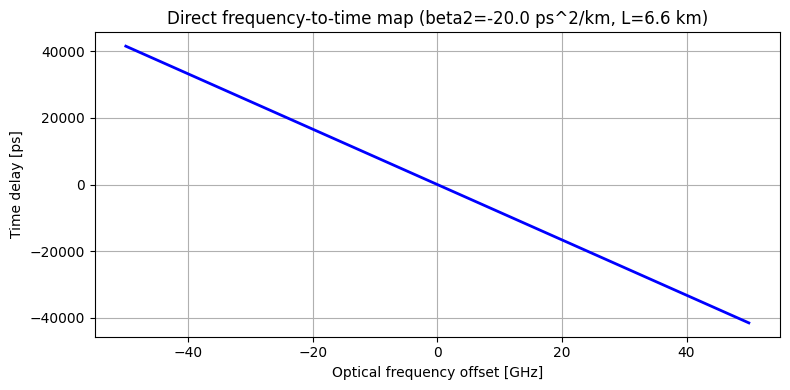

30 GHz -> -24.9 ps delay
This IS the STEAM camera mapping: frequency encodes spatial position.


In [7]:
# Direct time-to-wavelength: t = 2*pi*beta2*(L1+L2)*f
# For beta2=-20 ps^2/km, L1+L2=6.6km
L1v, L2v, b2v = 1.1, 5.5, -20.0
freqs_ghz = np.linspace(-50, 50, 200)
t_ps = 2*np.pi*(b2v*1e-24)*((L1v+L2v)*1e3)*(freqs_ghz*1e9)*1e12
plt.figure(figsize=(8,4))
plt.plot(freqs_ghz, t_ps, 'b-', lw=2)
plt.xlabel('Optical frequency offset [GHz]')
plt.ylabel('Time delay [ps]')
plt.title(f'Direct frequency-to-time map (beta2={b2v} ps^2/km, L={L1v+L2v} km)')
plt.grid(True)
plt.tight_layout()
plt.savefig('freq_to_time_map.png', dpi=100)
plt.show()

ex = freq_to_time_mapping(b2v, L1v+L2v, 30e9)
print(f"30 GHz -> {ex:.1f} ps delay")
print("This IS the STEAM camera mapping: frequency encodes spatial position.")

## Section 4 — Appendix Derivation: Time-Domain Field

This is the key derivation. Under the assumption $L_1\beta_2/\tau^2 \ll 1$
(pulse is already highly chirped by first fiber — pulse duration >> transform limit):

**Step 1:** Define $\gamma = 1 + j2L_1\beta_2\tau^{-2} \approx 1$

**Step 2:** Exponent $E_1$ of integrand $T_1(f)$ (Eq. A3-A4):
$$E_1 = j2\pi^2\beta_2(L_1\gamma + L_2)\left(f - \frac{L_1}{L_1+L_2}f_m\right)^2
+ j2\pi^2\beta_2\frac{L_1+L_2}{M}f_m^2$$

**Step 3:** Inverse FT of Gaussian in $f$ -> Gaussian in $t$:
- Center of Gaussian in frequency: $f_{eff} = f_m \cdot \frac{L_1}{L_1+L_2} = f_m/M$
- Output pulse width: $\tau_{out} = \tau \cdot M$ (pulse stretched by M!)

**Step 4:** Final result Eq.(6)/(7):
$$I_{out}(t) \propto \frac{1}{M^2}\exp\!\left(\frac{-2t^2}{(M\tau)^2}\right)
\left[1 + 2a\cos(2\pi f_m t/M)\right]\cdot H_{att}$$

The RF signal is preserved but *slowed down* by $M$ — $f_m \to f_m/M$.


In [8]:
print("=== Appendix: Symbolic Derivation ===")
results = derive_appendix_time_domain(verbose=True)

=== Appendix: Symbolic Derivation ===

--- gamma ---
2⋅ⅈ⋅L₁⋅β₂    
───────── + 1
    2        
   τ         

--- gamma_approx_L1_small ---
1

--- stretch_factor_M ---
    L₂
1 + ──
    L₁

--- shifted_freq_center ---
 L₁⋅fₘ 
───────
L₁ + L₂

--- interpretation ---
After second dispersion, each sideband is centered at fm*(L1/(L1+L2)) = fm/M i ↪

↪ n the output — frequency DIVIDED by M

--- output_pulse_width ---
  ⎛    L₂⎞
τ⋅⎜1 + ──⎟
  ⎝    L₁⎠

--- interpretation_2 ---
Pulse stretches by M — ADC sees tau*M, NOT tau

--- output_modulation_freq ---
  fₘ  
──────
    L₂
1 + ──
    L₁

--- interpretation_3 ---
fm mapped to fm/M — input 30GHz at M=6 -> 5GHz out

--- dispersion_penalty_H_att ---
    ⎛   2         2⎞
   2⎜2⋅π ⋅L₂⋅β₂⋅fₘ ⎟
cos ⎜──────────────⎟
    ⎜        L₂    ⎟
    ⎜    1 + ──    ⎟
    ⎝        L₁    ⎠

--- I_out_symbolic ---
                                    2                         
                                -2⋅t                          
                        

In [9]:
# Visualize the key result: M divides the modulation frequency
M_val = 6  # L2=5.5km, L1=1.1km
fm_input = 30  # GHz -- too fast for most ADCs
fm_output = fm_input / M_val
print(f"Input RF frequency: {fm_input} GHz")
print(f"Stretch factor M = {M_val}")
print(f"Output RF frequency = {fm_output:.1f} GHz -- ADC sees THIS")
print(f"Effective ADC bandwidth need reduced by {M_val}x")

# Show the gamma approximation error
import sympy as sp
tau_val = 2  # ps
b2_val = -20  # ps^2/km
L1_val = 1.1  # km
err = abs(2*L1_val*b2_val/tau_val**2)
print(f"gamma-1 = j*2*L1*beta2/tau^2 = j*{err:.3f} -- approximation error = {err*100:.1f}%")
print("(<<1 means gamma~1 is valid)")

Input RF frequency: 30 GHz
Stretch factor M = 6
Output RF frequency = 5.0 GHz -- ADC sees THIS
Effective ADC bandwidth need reduced by 6x
gamma-1 = j*2*L1*beta2/tau^2 = j*11.000 -- approximation error = 1100.0%
(<<1 means gamma~1 is valid)


## Section 5 — Eq. 8: The Stretch Factor M

$$\boxed{M = 1 + \frac{L_2}{L_1}}$$

This is **Jalali Grammar Equation #1** and the central result of the 1999 paper.

**Physical meaning:** The ADC only needs bandwidth $B/M$ to capture a $B$-bandwidth signal.
A 100 GHz signal with $M=10$ needs only a 10 GHz ADC.

**Experimental verification (Fig. 2 of paper):**
- $L_1 = 1.1$ km SMF (generates chirp)
- $L_2 = 2.2$ km -> $M = 3$
- $L_2 = 5.5$ km -> $M = 6$
- $L_2 = 7.6$ km -> $M = 8$

**Fiber in the field:** Laying fiber at $L_1 = 1.1$ km then $L_2 = 5.5$ km is a
standard dispersion-compensation spool configuration. The math works with standard
telecom SMF (G.652 fiber, $\beta_2 \approx -21.7$ ps$^2$/km at 1550 nm).


In [10]:
print("=== Fig.2 Stretch Factor Verification ===")
for r in verify_fig2_stretch_factors():
    status = "PASS" if r['match'] else "FAIL"
    print(f"L2={r['L2_km']}km: M_paper={r['M_paper']}, M_calc={r['M_calc']} [{status}]")

# SymPy symbolic M
M_sym = 1 + L2/L1
print("Symbolic M =", M_sym)
print("As L2->0: M =", M_sym.subs(L2, 0))
print("As L2->inf: M ->", sp.limit(M_sym, L2, sp.oo))

=== Fig.2 Stretch Factor Verification ===
L2=2.2km: M_paper=3, M_calc=3.0 [PASS]
L2=5.5km: M_paper=6, M_calc=6.0 [PASS]
L2=7.6km: M_paper=8, M_calc=7.9 [PASS]
Symbolic M = 1 + L_2/L_1
As L2->0: M = 1
As L2->inf: M -> oo


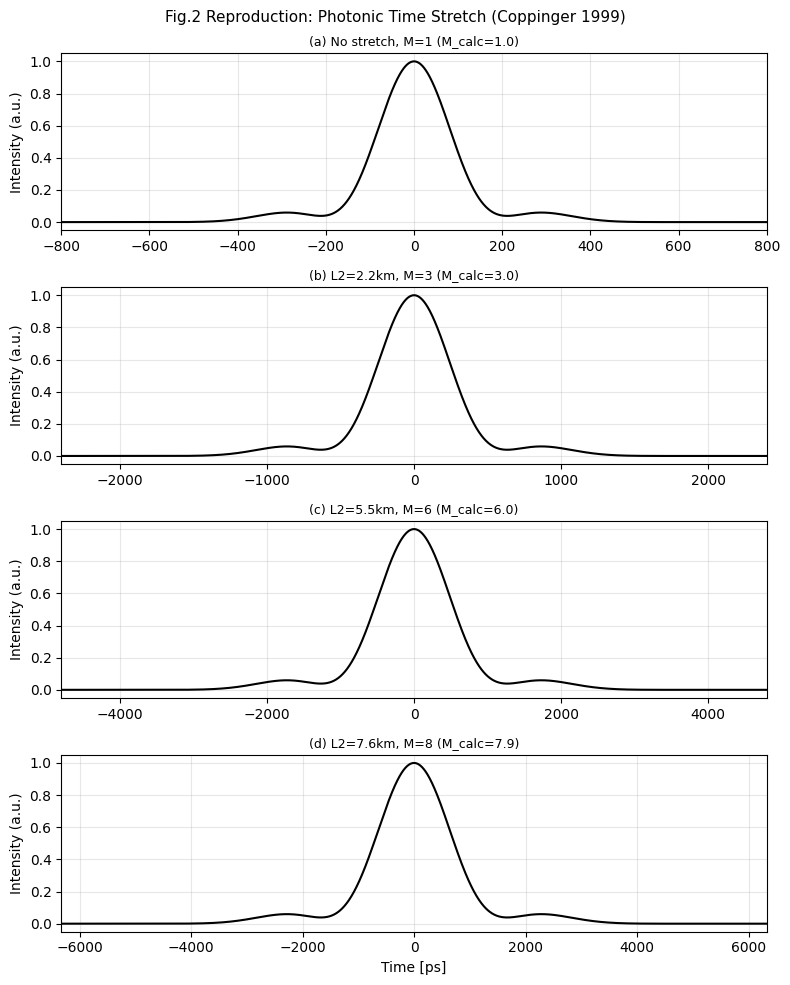

In [11]:
# Reproduce Fig.2 panels
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=False)
configs = [
    (0.0,  1.0,  '(a) No stretch, M=1'),
    (2.2,  3.0,  '(b) L2=2.2km, M=3'),
    (5.5,  6.0,  '(c) L2=5.5km, M=6'),
    (7.6,  8.0,  '(d) L2=7.6km, M=8'),
]
sims = simulate_fig2(L1_km=1.1, L2_values_km=[0.0,2.2,5.5,7.6],
                     beta2_ps2km=-20.0, tau_ps=200.0, fm_ghz=10.0, a_val=0.4)

for ax, (L2v, M_exp, label) in zip(axes, configs):
    t_arr, I_arr, M_calc = sims[L2v]
    ax.plot(t_arr, I_arr/I_arr.max(), 'k-', lw=1.5)
    ax.set_ylabel('Intensity (a.u.)')
    ax.set_title(label + f' (M_calc={M_calc:.1f})', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(t_arr[0], t_arr[-1])

axes[-1].set_xlabel('Time [ps]')
fig.suptitle('Fig.2 Reproduction: Photonic Time Stretch (Coppinger 1999)', fontsize=11)
plt.tight_layout()
plt.savefig('fig2_reproduction.png', dpi=100)
plt.show()

## Section 6 — Eq. 9: Dispersion Penalty

$$H_{att} = \left[\cos\!\left(\frac{2\pi^2\beta_2 L_2 f_m^2}{M}\right)\right]^2$$

**Why it's a low-pass filter:** The two sidebands at $\pm f_m$ travel at different group
velocities in the second fiber. They accumulate a relative phase shift. When they
interfere at the photodetector, the cosine factor gives partial cancellation.
At $f_m$ where the cosine = 0, the sidebands cancel completely -> signal is lost.

This is the **3 dB bandwidth limitation** of any dispersive link.
For conventional analog fiber link: same penalty but no stretch benefit.
For time-stretch link: penalty is reduced because the effective $\beta_2 L_2/M$
appears (the stretch factor in the denominator reduces the penalty).

**English vocabulary:** *attenuation* = weakening; *penalty* = cost you pay (in dB);
*bandwidth* = range of frequencies that pass without significant attenuation.


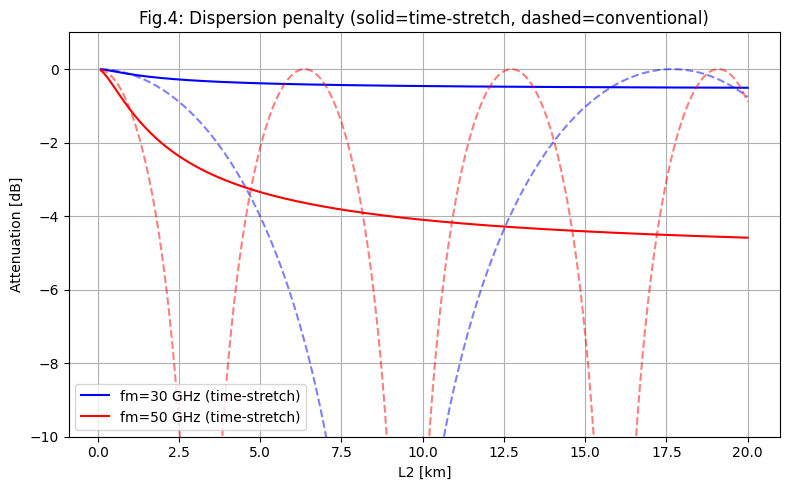

In [12]:
# Fig.4 reproduction: dispersion penalty vs L2 for fm=30,50 GHz
L2_arr = np.linspace(0.1, 20, 500)  # km
fig, ax = plt.subplots(figsize=(8,5))
for fm_ghz, color in [(30, 'b'), (50, 'r')]:
    pen_dB = []
    for L2v in L2_arr:
        M = 1 + L2v/1.0  # L1=1km as in paper Fig.4
        pen = eq9_dispersion_penalty(L2v, beta2_ps2km=-20, fm_ghz=fm_ghz, M=M)
        pen_dB.append(10*np.log10(pen+1e-30))
    ax.plot(L2_arr, pen_dB, color=color, label=f'fm={fm_ghz} GHz (time-stretch)')

    # Also show conventional (M=1, fixed wavelength carrier)
    pen_conv_dB = []
    for L2v in L2_arr:
        arg = np.pi**2*(20e-27)*(L2v*1e3)*(fm_ghz*1e9)**2  # pi not 2pi for conv
        pen_conv_dB.append(10*np.log10(np.cos(arg)**2 + 1e-30))
    ax.plot(L2_arr, pen_conv_dB, color=color, linestyle='--', alpha=0.5)

ax.set_xlabel('L2 [km]')
ax.set_ylabel('Attenuation [dB]')
ax.set_title('Fig.4: Dispersion penalty (solid=time-stretch, dashed=conventional)')
ax.legend()
ax.set_ylim(-10, 1)
ax.grid(True)
plt.tight_layout()
plt.savefig('fig4_penalty.png', dpi=100)
plt.show()

## Section 7 — Connection to This Repo

| Paper equation | This repo | Where |
|---|---|---|
| $H(f)=\exp(j2\pi^2 L\beta_2 f^2)$ | `D = 2*pi^2*L*beta2` | `dgs/gs_core.py` |
| $M=1+L_2/L_1$ | `jalali_grammar.time_stretch_factor()` | `dgs/jalali_grammar.py` |
| GS iterations on $|E_{out}|^2$ | `retrieve_phase()` | `dgs/gs_core.py` |
| NLSE nonlinear extension | `phi_NL = gamma*P*L` | `dgs/nlse.py` |
| STEAM cell classification | CNN/DL block | `dgs/edge_ai_protocols.py` |
| CRISPR phase shift detection | `delta_phi = 4e-4 rad` | `notebooks/crispr_steam_theory.ipynb` |

**The GS algorithm inverts $H(f)$:** Given the detected intensity $|E_{out}|^2$,
GS recovers the unknown phase by alternating between the two planes
(before and after the dispersive fiber), using $H$ as the forward propagator
and $H^*$ as the backward propagator.

**SBIR relevance:** This 1999 paper is the physical foundation of **all 6 SBIR proposals**
(P1-P7) in `dgs/sbir_portfolio.py`. Citing it in a grant = citing the field's genesis.


GS recovery: final correlation = 3.3429
This uses H(f)=exp(j*pi*D*f^2) where D1=5000, D2=-5000 ps^2
Paper's notation: D = 2*pi^2*L*beta2


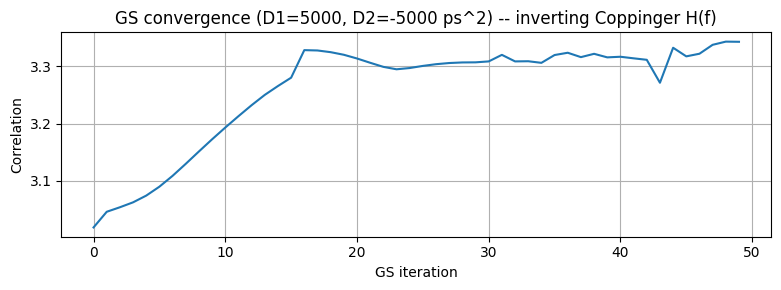

In [13]:
# Show the GS connection
from dgs.gs_core import retrieve_phase
import numpy as np

N = 256
D1, D2 = 5000, -5000  # ps^2: D1 first fiber, D2 second fiber
t_axis = np.linspace(-1, 1, N)
signal = np.exp(-t_axis**2/0.1**2) * (1 + 0.3*np.cos(2*np.pi*5*t_axis))
I1 = np.abs(signal)**2  # plane 1 intensity
I2 = np.abs(signal)**2  # plane 2 (same for demo -- GS will recover phase)

phase_recovered, corr_history = retrieve_phase(I1, I2, D1=D1, D2=D2, n_iter=50)
print(f"GS recovery: final correlation = {corr_history[-1]:.4f}")
print(f"This uses H(f)=exp(j*pi*D*f^2) where D1={D1}, D2={D2} ps^2")
print(f"Paper's notation: D = 2*pi^2*L*beta2")

plt.figure(figsize=(8,3))
plt.plot(corr_history)
plt.xlabel('GS iteration')
plt.ylabel('Correlation')
plt.title(f'GS convergence (D1={D1}, D2={D2} ps^2) -- inverting Coppinger H(f)')
plt.grid(True)
plt.tight_layout()
plt.savefig('gs_convergence.png', dpi=100)
plt.show()

## Summary

| Concept | Paper equation | English meaning |
|---|---|---|
| Chirped pulse | $e^{-t^2/\tau^2}$ | Gaussian pulse — duration $\tau$ |
| GVD chirp | $e^{-j f^2/(2L_1\beta_2)}$ | Color-speed difference stretches pulse |
| MZM modulation | $\times[1+a\cos(2\pi f_m t)]$ | RF signal encoded on optical carrier |
| Dispersion (FT duality) | $E_{out} = E_{in}\cdot e^{j\pi Df^2}$ | Quadratic phase = time lens |
| Stretch factor | $M=1+L_2/L_1$ | ADC sees signal M times slower |
| Frequency-to-time | $t = 2\pi\beta_2(L_1+L_2)f$ | Wavelength becomes position/time |
| Dispersion penalty | $\cos^2(2\pi^2\beta_2 L_2 f_m^2/M)$ | High-frequency rolloff |

**Test-prep vocabulary built:** chirp, dispersion, group velocity dispersion (GVD),
modulation depth, stretch factor, sidebands, dispersion penalty, quadrature bias,
time-bandwidth product, direct time-to-wavelength, free spectral range.
